<a href="https://colab.research.google.com/github/KP-365/hybrid-ope-lending/blob/main/XGBModel/Model1propensity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Propensity model (model 1)
Predicts whether Lending Club accepted an application. Its probabilities become the IPS/DR weights (1 ÷ p), so they must be **free of leaks** and **well calibrated**.

## Setup
Mount Drive, import libraries and load the datasets saved by the cleaning notebook.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, log_loss
import numpy as np
from sklearn.calibration import calibration_curve
from matplotlib import pyplot as plt

In [3]:
DATA_DIR = '/content/drive/MyDrive/hybrid-ope-lending'
combined = pd.read_parquet(f'{DATA_DIR}/lending_club_combined.parquet')
outcome_df = pd.read_parquet(f'{DATA_DIR}/lending_club_outcome.parquet')

Store dates as monthly periods (accepted loans only record the month).

In [4]:
combined["date"] = combined["date"].dt.to_period("M")

In [5]:
combined

,id,amount,date,purpose,risk_score,dti,zip3,state,emp_length,accepted,in_ope_period,year,month
0,68407277.0,3600.0,2015-12,debt_consolidation,677.0,5.91,190,PA,10+ years,1,0,2015,12
1,68355089.0,24700.0,2015-12,small_business,717.0,16.06,577,SD,10+ years,1,0,2015,12
2,68341763.0,20000.0,2015-12,home_improvement,697.0,10.78,605,IL,10+ years,1,0,2015,12
3,66310712.0,35000.0,2015-12,debt_consolidation,787.0,17.06,076,NJ,10+ years,1,0,2015,12
4,68476807.0,10400.0,2015-12,major_purchase,697.0,25.37,174,PA,3 years,1,0,2015,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29749862,NaN,10000.0,2016-12,debt_consolidation,590.0,41.26,441,OH,< 1 year,0,0,2016,12
29749863,NaN,10000.0,2016-12,moving,NaN,1.48,207,MD,5 years,0,0,2016,12
29749864,NaN,1200.0,2016-12,other,686.0,10.26,914,CA,< 1 year,0,0,2016,12
29749865,NaN,25000.0,2016-12,debt_consolidation,NaN,17.71,880,NM,< 1 year,0,0,2016,12


Share of applications per year: most of the data comes after 2014.

In [6]:
year_counts = combined.groupby(combined['date'].dt.year).size()
percentage = year_counts / combined['date'].count()
percentage

,0
date,
2007,0.000197
2008,0.000940
2009,0.002092
2010,0.004197
2011,0.008035
2012,0.013110
2013,0.030006
2014,0.072409
2015,0.109877


Train on 2007–2017, test on 2018 (a year the model has never seen).

## First model: all features
Drop `id` and `date` (year and month stay as features). Purpose is mapped to numbers; zip, state and employment length become categories.

In [7]:
propensity_data = combined.drop(columns=['id','date'])

In [8]:
set(propensity_data['purpose'])

{'car',
 'credit_card',
 'debt_consolidation',
 'educational',
 'home_improvement',
 'house',
 'major_purchase',
 'medical',
 'moving',
 'other',
 'renewable_energy',
 'small_business',
 'vacation',
 'wedding'}

In [9]:
propensity_data.columns

Index(['amount', 'purpose', 'risk_score', 'dti', 'zip3', 'state', 'emp_length',
       'accepted', 'in_ope_period', 'year', 'month'],
      dtype='object')

In [10]:
features = ['amount', 'month', 'year', 'purpose', 'risk_score', 'dti', 'zip3', 'state','emp_length']
outcome = ['accepted']

cat_map = {'car' : 1,
 'credit_card' : 2,
 'debt_consolidation' : 3,
 'educational' : 4,
 'home_improvement' : 5,
 'house': 6,
 'major_purchase': 7,
 'medical': 8,
 'moving' : 9,
 'other' : 10,
 'renewable_energy' : 11,
 'small_business' : 12,
 'vacation' : 13,
 'wedding' : 14}

month_map = {'Jan' : 1,
              'Feb' : 2,
              'Mar' : 3,
              'Apr' : 4,
              'May' : 5,
              'Jun' : 6,
              'Jul' : 7,
              'Aug' : 8,
              'Sep' : 9,
              'Oct' : 10,
              'Nov' : 11,
              'Dec' : 12}

In [11]:
propensity_data['purpose'] = propensity_data['purpose'].map(cat_map)
propensity_data['zip3'] = propensity_data['zip3'].astype('category')
propensity_data['state'] = propensity_data['state'].astype('category')
propensity_data['emp_length'] = propensity_data['emp_length'].astype('category')

In [12]:
set(propensity_data['month'])

{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12}

Split by time.

In [13]:
train = propensity_data[propensity_data['year'] < 2018]
test = propensity_data[propensity_data['year'] == 2018]

In [14]:
test

,amount,purpose,risk_score,dti,zip3,state,emp_length,accepted,in_ope_period,year,month
421095,5000.0,10,667.0,21.80,740,OK,8 years,1,0,2018,3
421096,15000.0,3,702.0,18.29,337,FL,2 years,1,0,2018,3
421097,11200.0,8,667.0,43.97,030,NH,< 1 year,1,0,2018,3
421098,25000.0,3,667.0,12.89,361,AL,10+ years,1,0,2018,3
421099,3000.0,7,762.0,0.58,988,WA,9 years,1,0,2018,3
...,...,...,...,...,...,...,...,...,...,...,...
21834613,17000.0,2,NaN,26.60,301,GA,< 1 year,0,0,2018,6
21834614,2000.0,12,NaN,0.00,117,NY,< 1 year,0,0,2018,6
21834615,2500.0,1,567.0,0.00,366,AL,2 years,0,0,2018,6
21834616,4500.0,10,NaN,4.65,780,TX,< 1 year,0,0,2018,6


In [15]:
X_train = train[features]
y_train = train[outcome]
X_test = test[features]
y_test = test[outcome]

Train XGBoost and check log loss (lower is better).

In [16]:
model = xgb.XGBClassifier(tree_method='hist', enable_categorical=True)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [17]:
log_loss(y_test, model.predict_proba(X_test)[:,1])

0.013049662744678834

Calibration curve: when the model predicts 80%, were 80% really accepted?

In [18]:
calibration = calibration_curve(y_test, model.predict_proba(X_test)[:,1], n_bins= 20)

In [19]:
calibration

(array([2.93248918e-04, 4.27087164e-01, 5.37319854e-01, 5.88864143e-01,
        6.45075421e-01, 7.09168185e-01, 7.57926612e-01, 8.14917127e-01,
        8.47826087e-01, 8.80000000e-01, 9.05692081e-01, 9.23265460e-01,
        9.50132049e-01, 9.64771817e-01, 9.76508046e-01, 9.83216262e-01,
        9.88069909e-01, 9.92252013e-01, 9.94322276e-01, 9.97447459e-01]),
 array([8.67904651e-05, 7.34545550e-02, 1.24979226e-01, 1.74750401e-01,
        2.24320885e-01, 2.74550751e-01, 3.24702957e-01, 3.75067271e-01,
        4.24983236e-01, 4.74850858e-01, 5.25202747e-01, 5.75747180e-01,
        6.26124948e-01, 6.76190191e-01, 7.26184802e-01, 7.76506043e-01,
        8.27496724e-01, 8.77934285e-01, 9.29650497e-01, 9.71670209e-01]))

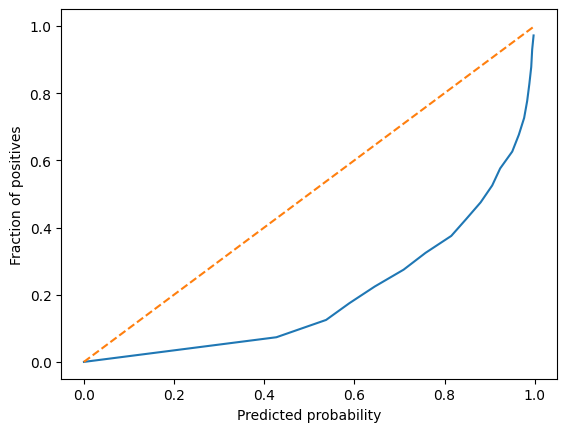

In [20]:

plt.plot(calibration[0], calibration[1])
plt.plot([0,1], [0,1], linestyle = '--')
plt.xlabel('Predicted probability')
plt.ylabel('Fraction of positives')
plt.show()

**Result: log loss 0.013 vs a ≈0.199 baseline (predicting the 5% average for everyone).** Far too good, so something is leaking.

Feature importance: `emp_length` and `risk_score` dominate.

In [21]:
feature_imp = dict(zip(features, model.feature_importances_))
feature_imp

{'amount': np.float32(0.03243554),
 'month': np.float32(0.031474505),
 'year': np.float32(0.044054493),
 'purpose': np.float32(0.015256907),
 'risk_score': np.float32(0.38994947),
 'dti': np.float32(0.0459151),
 'zip3': np.float32(0.002601574),
 'state': np.float32(0.0006960037),
 'emp_length': np.float32(0.43761647)}

## Leak 1: employment length
86% of rejected applications record "< 1 year" (vs 9% of accepted), jumping from 27% to 66% between 2009 and 2010. That's a recording placeholder in the rejected file, not real data. **Removed from both models.**

In [22]:
# share of each employment length within accepted vs rejected
print(pd.crosstab(combined['emp_length'], combined['accepted'], normalize='columns').round(3))

# share of rejected applicants with "< 1 year", by year
rej = combined[combined['accepted'] == 0]
(rej['emp_length'] == '< 1 year').groupby(rej['year']).mean().round(3)

accepted        0      1
emp_length              
1 year      0.010  0.070
10+ years   0.016  0.354
2 years     0.007  0.096
3 years     0.007  0.086
4 years     0.005  0.065
5 years     0.086  0.066
6 years     0.003  0.049
7 years     0.002  0.044
8 years     0.002  0.043
9 years     0.002  0.038
< 1 year    0.861  0.090


,emp_length
year,
2007,0.273
2008,0.260
2009,0.290
2010,0.664
2011,0.834
2012,0.868
2013,0.856
2014,0.877
2015,0.858


Retrain without `emp_length`.

In [23]:
X_train_noemp = train[features].drop(columns=['emp_length'])
y_train_noemp = train[outcome]
X_test_noemp = test[features].drop(columns=['emp_length'])
y_test_noemp = test[outcome]

In [24]:
model_noemp = xgb.XGBClassifier(tree_method='hist', enable_categorical=True)
model_noemp.fit(X_train_noemp, y_train_noemp)
log_loss(y_test_noemp, model_noemp.predict_proba(X_test_noemp)[:,1])

0.024825639260756618

**Log loss 0.025: still far too good.**

## Leak 2: missing risk scores
How many predictions are near 0, split by whether the applicant has a score.

In [25]:
p = model_noemp.predict_proba(X_test_noemp)[:, 1]

print('below 0.001:', (p < 0.001).mean().round(3), '| above 0.999:', (p > 0.999).mean().round(3))

below 0.001: 0.936 | above 0.999: 0.0


In [26]:
missing = X_test_noemp['risk_score'].isna().to_numpy()

print('score missing: share below 0.001 =', (p[missing] < 0.001).mean().round(3), '| rows:', missing.sum())
print('score present: share below 0.001 =', (p[~missing] < 0.001).mean().round(3), '| rows:', (~missing).sum())

score missing: share below 0.001 = 1.0 | rows: 8768643
score present: share below 0.001 = 0.445 | rows: 1141684


**Every applicant without a score gets p < 0.001.** Accepted loans almost always have a score, so "missing" means "rejected file". **Fix: use only applicants with a score.**

## Leak 3: the score fingerprint
Last digit pattern of scores (score % 5) by group.

In [27]:
scored = combined[combined['risk_score'].notna()]

In [28]:
pd.crosstab(scored['accepted'], scored['risk_score'].astype(int) % 5, normalize='index').round(3)

risk_score,0,1,2,3,4
accepted,,,,,
0,0.195,0.212,0.196,0.202,0.195
1,0.000,0.000,1.000,0.000,0.000


Accepted scores are FICO range midpoints, so they **always end in 2 or 7** (score % 5 = 2); rejected scores are spread evenly. **Fix: floor all scores to 5-point bands (`// 5 * 5`), FICO's own ranges, for both groups.**

Retrain with banded scores (applicants without a score still included here).

In [29]:
X_test_noemp_risk = X_test_noemp.copy()
X_test_noemp_risk['risk_score'] = test['risk_score'] // 5 * 5
X_train_noemp_risk = X_train_noemp.copy()
X_train_noemp_risk['risk_score'] = train['risk_score'] // 5 * 5

In [30]:
model_noemp_risk = xgb.XGBClassifier(tree_method='hist', enable_categorical=True)
model_noemp_risk.fit(X_train_noemp_risk, y_train_noemp)
log_loss(y_test_noemp, model_noemp_risk.predict_proba(X_test_noemp_risk)[:,1])

0.05731327970335965

**Log loss 0.057.**

Compare calibration for the three diagnostic models.

In [31]:
calibration_risk_noemp = calibration_curve(y_test_noemp, model_noemp_risk.predict_proba(X_test_noemp_risk)[:,1], n_bins= 20)
calibration_noemp = calibration_curve(y_test_noemp, model_noemp.predict_proba(X_test_noemp)[:,1], n_bins= 20)

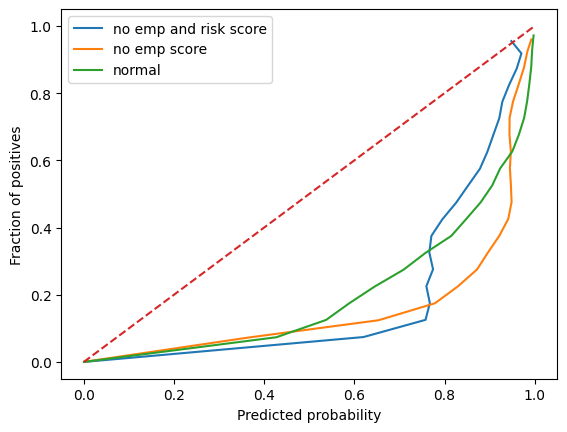

In [32]:
plt.plot(calibration_risk_noemp[0], calibration_risk_noemp[1], label='no emp and risk score')
plt.plot(calibration_noemp[0], calibration_noemp[1], label='no emp score')
plt.plot(calibration[0], calibration[1], label = 'normal')
plt.plot([0,1], [0,1], linestyle = '--')
plt.xlabel('Predicted probability')
plt.ylabel('Fraction of positives')
plt.legend()
plt.show()

**All three curves sit below the diagonal: they over-predict approval on 2018**, due to the leaks and the drop in acceptance rate in 2018. These models were diagnostics for finding leaks; none is used for OPE.

## Fixed model (the one used for OPE)
- Only applicants **with a risk score**; scores **banded** to 5 points; **no `emp_length`**.
- 20% of 2007–2014 held out as `calib`, to check calibration where the OPE weights are used.
- Rejected rows sampled (f = 0.644) and weighted 1 ÷ f, so the probabilities stay correct.

In [33]:
FIXED_FEATURES = ['amount', 'purpose', 'risk_score', 'dti', 'zip3', 'state', 'year', 'month']

# rows with a score, banded into 5-point groups
scored = combined[combined['risk_score'].notna()].copy()
scored['risk_score'] = scored['risk_score'] // 5 * 5

# hold out 20% of 2007-2014 to check calibration where the IPS weights are used
calib = scored[scored['in_ope_period'] == 1].sample(frac=0.2, random_state=42)
rest = scored.drop(calib.index)

train = rest[rest['year'] <= 2017]
test = rest[rest['year'] == 2018]

# choose f from the training rows
n_acc = (train['accepted'] == 1).sum()
n_rej = (train['accepted'] == 0).sum()
f = min(1.0, 3 * n_acc / n_rej)   # about 3 rejected per accepted, never more than all of them
print('accepted:', n_acc, '| rejected:', n_rej, '| f =', round(f, 3))

# sample rejected rows for training only, with weights
keep = (train['accepted'] == 1) | (np.random.default_rng(42).random(len(train)) < f)
train = train[keep]
w_train = np.where(train['accepted'] == 1, 1.0, 1 / f)

model_fixed = xgb.XGBClassifier(tree_method='hist', enable_categorical=True)
model_fixed.fit(train[FIXED_FEATURES], train['accepted'], sample_weight=w_train)

accepted: 1672241 | rejected: 7787373 | f = 0.644


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [34]:
log_loss(test['accepted'], model_fixed.predict_proba(test[FIXED_FEATURES])[:,1])

0.496518235278472

Compare with a **baseline** that predicts the average acceptance rate for everyone, on the same test set.

In [35]:
def compare_to_baseline(y_true, p):
    rate = y_true.mean()
    baseline = log_loss(y_true, np.full(len(y_true), rate))
    model = log_loss(y_true, p)
    print(f'acceptance rate {rate:.3f} | baseline {baseline:.3f} | model {model:.3f} | {baseline / model:.1f}x better')


In [36]:
# 1. exact baseline on the same test set
compare_to_baseline(test['accepted'], model_fixed.predict_proba(test[FIXED_FEATURES])[:, 1])

# 2. the same on the calibration hold-out (2007-2014): the period that matters for OPE
p_calib = model_fixed.predict_proba(calib[FIXED_FEATURES])[:, 1]
compare_to_baseline(calib['accepted'], p_calib)

# 3. overlap on 2007-2014: how extreme will the IPS weights get?
print('min p:', p_calib.min().round(4), '| share below 0.01:', (p_calib < 0.01).mean().round(3),
      '| share below 0.05:', (p_calib < 0.05).mean().round(3))

acceptance rate 0.434 | baseline 0.684 | model 0.497 | 1.4x better
acceptance rate 0.132 | baseline 0.391 | model 0.176 | 2.2x better
min p: 0.0 | share below 0.01: 0.641 | share below 0.05: 0.672


- **2018:** 0.497 vs 0.684 baseline (1.4× better).
- **2007–2014 hold-out:** 0.176 vs 0.391 (2.2× better). This is the period that matters.
- Realistic: clearly learned, not "perfect", as expected when Lending Club used information we don't have.
- 64% of 2007–2014 applicants have p < 0.01.

Calibration on the 2007–2014 hold-out:

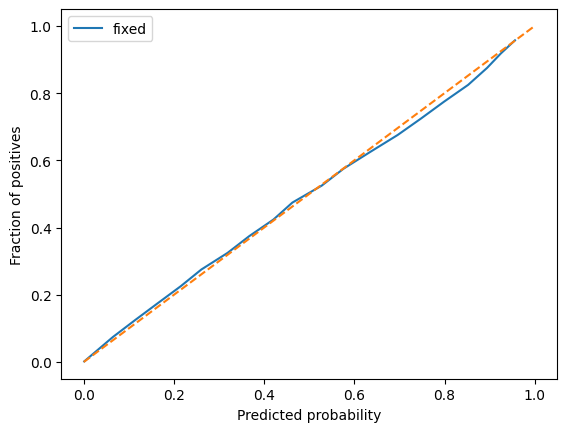

In [37]:
calibration_fixed = calibration_curve(calib['accepted'], p_calib, n_bins=20)
plt.plot(calibration_fixed[0], calibration_fixed[1], label='fixed')
plt.plot([0,1], [0,1], linestyle = '--')
plt.xlabel('Predicted probability')
plt.ylabel('Fraction of positives')
plt.legend()
plt.show()


**On the diagonal: the probabilities can be trusted for IPS/DR weights.** Propensity model done.

## Overlap
DR can only evaluate a policy where Lending Club **sometimes approved and sometimes rejected** similar applicants. Compare the approval probabilities of the two groups.

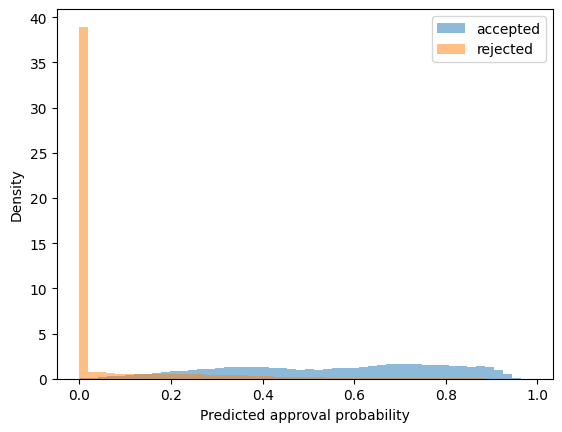

In [38]:
acc = calib['accepted'].to_numpy() == 1
plt.hist(p_calib[acc], bins=50, alpha=0.5, density=True, label='accepted')
plt.hist(p_calib[~acc], bins=50, alpha=0.5, density=True, label='rejected')
plt.xlabel('Predicted approval probability'); plt.ylabel('Density'); plt.legend(); plt.show()

- **Rejected spike at 0:** most rejected applicants had no chance (Lending Club's hard rules, e.g. minimum score). No overlap; no method can evaluate approving them.
- **Overlap between about 0.05 and 0.5:** target policies should change decisions here. The low end is the thin-overlap zone the hybrid method targets.
- **Few accepted loans near 0**, so no extreme weights from accepted loans.

# Save model to drive

In [39]:
model_fixed.save_model('/content/drive/MyDrive/hybrid-ope-lending/propensity_model.json')